# Q3. Dimensionality Reduction

Principal Component Analysis (PCA) is used here to reduce the dimensionality of the 5D AGN color space ($u-g$, $g-r$, $r-i$, $i-z$, and $z-y$). PCA identifies the directions of maximum variance. The primary purpose is to determine if the complex variations across our 100 AGNs can be explained by a smaller set of "base" components. This allows us to compress the data while retaining the critical physical information necessary to reconstruct the original photometric profiles.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Load data

In [6]:
# Load light curve data from FITS files
# Change path to the directory containing the FITS files on your computer
path = Path("C:\\Users\\natha\\Downloads\\Lightcurve Data")

# Initialize a list to hold the data from all files
all_data = []

# Loop over all FITS files in the directory
for fits_file in path.glob("*.fits"):

    bands = {} # Dictionary to hold the data from this file
    
    with fits.open(fits_file) as hdul:
        # data type: ndarray of many ndarray of 3 float64
        data_uband = hdul[1].data
        data_gband = hdul[2].data
        data_rband = hdul[3].data
        data_iband = hdul[4].data
        data_zband = hdul[5].data
        data_yband = hdul[6].data
    
# Make 3 ndarray of float64 (time, mag, mag_error) for each band
    # uband
    time_uband = data_uband[:, 0]
    mag_uband = data_uband[:, 1]
    mag_error_uband = data_uband[:, 2]

    # gband
    time_gband = data_gband[:, 0]
    mag_gband = data_gband[:, 1]
    mag_error_gband = data_gband[:, 2]

    # rband
    time_rband = data_rband[:, 0]
    mag_rband = data_rband[:, 1]
    mag_error_rband = data_rband[:, 2]

    # iband
    time_iband = data_iband[:, 0]
    mag_iband = data_iband[:, 1]
    mag_error_iband = data_iband[:, 2]

    # zband
    time_zband = data_zband[:, 0]
    mag_zband = data_zband[:, 1]
    mag_error_zband = data_zband[:, 2]

    # yband
    time_yband = data_yband[:, 0]
    mag_yband = data_yband[:, 1]
    mag_error_yband = data_yband[:, 2]

# Add time, mag, mag_error to dictionary for each band
    u = {
        'time': time_uband,
        'mag': mag_uband,
        'mag_error': mag_error_uband
    }

    g = {
        'time': time_gband,
        'mag': mag_gband,
        'mag_error': mag_error_gband
    }

    r = {
        'time': time_rband,
        'mag': mag_rband,
        'mag_error': mag_error_rband
    }
    
    i = {
        'time': time_iband,
        'mag': mag_iband,
        'mag_error': mag_error_iband
    }

    z = {
        'time': time_zband,
        'mag': mag_zband,
        'mag_error': mag_error_zband
    }

    y = {
        'time': time_yband,
        'mag': mag_yband,
        'mag_error': mag_error_yband
    }
    
# Add dictionary for each band in a master dictionary for this file
    bands = {
        'u': u,
        'g': g,
        'r': r,
        'i': i,
        'z': z,
        'y': y
    }

# Append the master dictionary for this file to the master list
    all_data.append(bands)
    # print(f"Loaded file: {fits_file.name}")

#### Extracting data to which we will apply different algorithms

In [8]:
# Get mean magnitudes for u, g, r, i, z, y bands
u = np.array([np.mean(d["u"]['mag']) for d in all_data])
g = np.array([np.mean(d["g"]['mag']) for d in all_data])
r = np.array([np.mean(d["r"]['mag']) for d in all_data])
i = np.array([np.mean(d["i"]['mag']) for d in all_data])
z = np.array([np.mean(d["z"]['mag']) for d in all_data])
y = np.array([np.mean(d["y"]['mag']) for d in all_data])

# Get mean magnitude differences
u_minus_g = u - g
g_minus_r = g - r
r_minus_i = r - i
i_minus_z = i - z
z_minus_y = z - y

#### Formatting data to which we will apply different algorithms

In the two graphs below (in section "Plotting data to which we will apply different algorithms"), we see that there are a few outliers. Since I have not taken a cosmology class, I do not know if this follows the normal behavior for quasars. Therefore, I make a data set for u-g vs. g-r with and without those outliers. For question 4, it makes a significant different in how the algorithms apply to the data.

##### Without outliers

In [12]:
# Remove outliers
mask = u_minus_g > -5

# Format clean color data in an array
clean_colors = np.column_stack((u_minus_g[mask], 
                                    g_minus_r[mask],
                                    r_minus_i[mask],
                                    i_minus_z[mask],
                                    z_minus_y[mask]))

##### With outliers

In [14]:
# Format color data in an array 
colors = np.column_stack((u_minus_g, 
                              g_minus_r,
                              r_minus_i,
                              i_minus_z,
                              z_minus_y))

#### Plotting data to which we will apply different algorithms

##### Without outliers

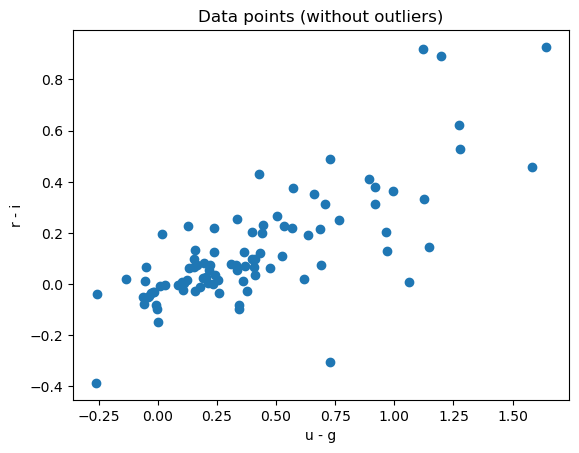

In [17]:
# Plot u-g vs r-i (for example)
plt.scatter(clean_colors[:, 0], 
            clean_colors[:, 2])

plt.xlabel('u - g')
plt.ylabel('r - i')
plt.title('Data points (without outliers)')
plt.show()

##### With outliers

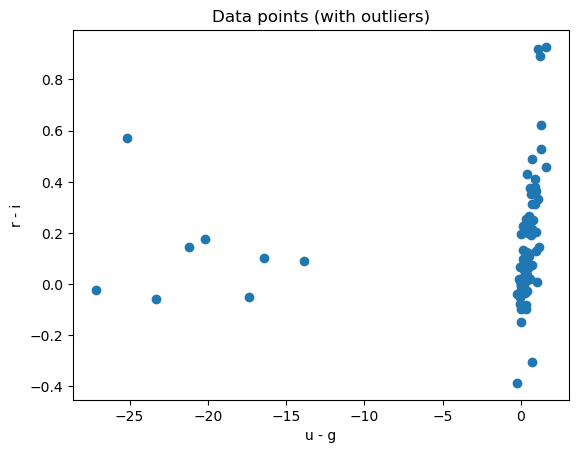

In [19]:
# Plot u-g vs r-i (for example)
plt.scatter(colors[:, 0],
            colors[:, 2])

plt.xlabel('u - g')
plt.ylabel('r - i')
plt.title('Data points (with outliers)')
plt.show()

## a) Perform Dimensionality Reduction (PCA)

#### Use the sklearn.decomposition.PCA function to perform dimensionality reduction on some data (e.g., from your research).

In [22]:
# ==========================================
# STEP 1: Standardize the data
# ==========================================
# PCA is highly sensitive to the scale of the features
# We must center the data (mean = 0) and standardize it (scale the variance to 1)
# This means: X_scaled = (X - mean(X)) / std(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clean_colors)

# ==========================================
# STEP 2: Initialize the PCA model
# ==========================================
# Decide how many principal components you want to keep
n_components_to_keep = 5
pca_model = PCA(n_components=n_components_to_keep)

# ==========================================
# STEP 3: Run PCA on standardized data
# ==========================================
# Fit the model and transform the data
X_reduced = pca_model.fit_transform(X_scaled)

# Extract the eigenvalues
exp_var_pca = pca_model.explained_variance_ratio_
cumulative_variance = np.cumsum(exp_var_pca)

#### Make plots that visualize your principal components.

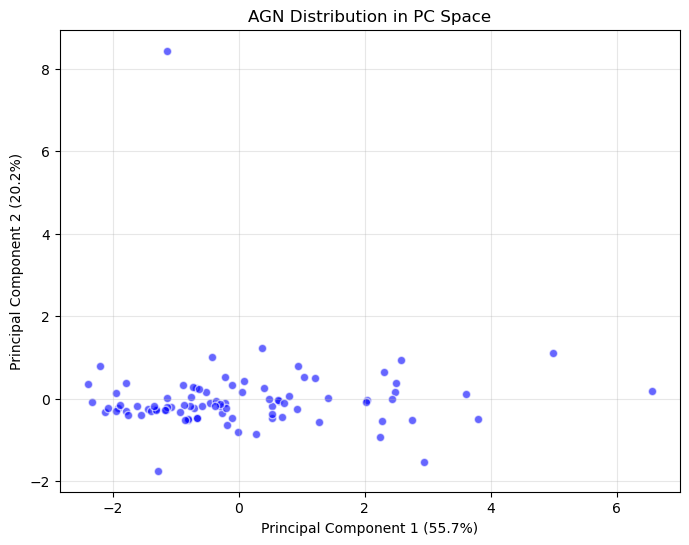

In [24]:
# Score Plot
plt.figure(figsize=(8, 6))
# Plot the first two principal components
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c='blue', alpha=0.6, edgecolors='w')

plt.xlabel(f'Principal Component 1 ({exp_var_pca[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({exp_var_pca[1]*100:.1f}%)')
plt.title('AGN Distribution in PC Space')
plt.grid(True, alpha=0.3)
plt.show()

From this score plot, we see that the first principal component explains the majority of the variance in the data. This is a good indicator that it is a good PC for dimensionality reduction, since a lot of the information contained in the data can be explained by it. In this new coordinate system, the axes no longer represent single colors, but rather the most significant combinations of colors that differentiate the objects. This visualization is essential for spotting outliers that deviate from the standard AGN color-color relationships such as the data point at around (-1, 8).

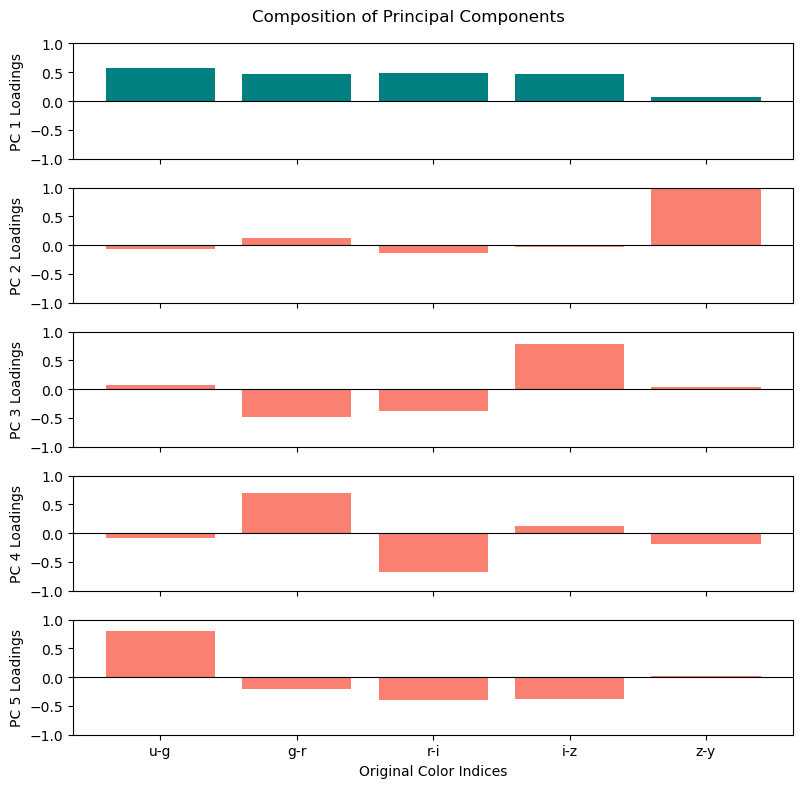

In [26]:
# Loadings plot
features = ['u-g', 'g-r', 'r-i', 'i-z', 'z-y']

# Get loadings for the components
loadings = pca_model.components_

fig, ax = plt.subplots(5, 1, figsize=(8, 8), sharex=True)

for i in range(5): # Plotting PCs
    ax[i].bar(features, loadings[i], color='teal' if i==0 else 'salmon')
    ax[i].set_ylabel(f'PC {i+1} Loadings')
    ax[i].set_ylim(-1, 1) # Loadings are usually between -1 and 1
    ax[i].axhline(0, color='black', linewidth=0.8)

plt.xlabel('Original Color Indices')
plt.suptitle('Composition of Principal Components')
plt.tight_layout()
plt.show()

The loadings plot identifies the weight or contribution of each original color index to a given principal component. Each bar represents the extent to which a specific color (like $u-g$ or $z-y$) defines the direction of that PC in the feature space. For example, if $z-y$ has a loading near zero on PC1, then PC1 captures very little of that color's variance; consequently, a 1-PC reconstruction would fail to represent the specific $z-y$ characteristics of an individual object.

## b) Scree Plot

#### Make a scree plot to identify the ideal number of principal components that can represent your data.

Original shape: (92, 5) (Objects, Dimensions)
Reduced shape: (92, 5) (Objects, Number of Principal Components)
Variance explained by each principal component: [0.55738205 0.20159025 0.11452865 0.10132362 0.02517543]
Total variance explained: 1.00


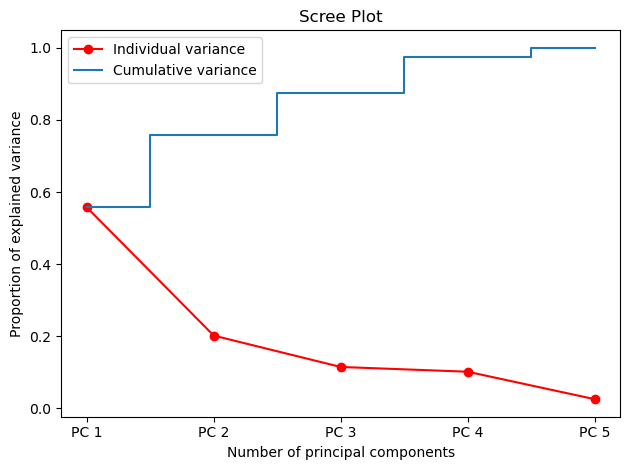

In [30]:
# ==========================================
# STEP 4: Analyze the results
# ==========================================
# Check how much variance is explained by the components
# This helps you decide how many components are enough to explain the data well

print(f"Original shape: {clean_colors.shape} (Objects, Dimensions)")
print(f"Reduced shape: {X_reduced.shape} (Objects, Number of Principal Components)")
print(f"Variance explained by each principal component: {exp_var_pca}")
print(f"Total variance explained: {cumulative_variance[-1]:.2f}")


# Plot the scree plot
pc_labels = [f"PC {i+1}" for i in range(len(exp_var_pca))]

plt.plot(pc_labels, exp_var_pca, 'r-o', label='Individual variance')
plt.step(pc_labels, cumulative_variance, where='mid', label='Cumulative variance')
plt.xlabel('Number of principal components')
plt.ylabel('Proportion of explained variance')
plt.title('Scree Plot')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

From this scree plot, we can identify the "elbow" as the the principal component where the slope of the explained variance becomes mostly flat. When we keep the PCs up to the "elbow", this means that we reduce that dimensionality of the data as much as possible while retaining the most information possible.

In this case, the slope becomes mostly flat starting from PC 3. Therefore, we can say that PCs 1, 2, and 3 hold enough significance about the data to reconstruct it well. Indeed, those 3 PCs explain about 87% of the variance in the data. This means that we can reduce the dimensionality of our data from 5 to 3. Here, we only have about 100 AGN light curves in the dataset. If we eventually need to analyze a growing number of such light curves, then this reduction of dimensionality becomes more and more useful.

## c) Plot reconstructions of your data using different numbers of principal components

#### Plot reconstructions of your data using different numbers of principal components, to show that the reconstruction improves if you use more principal components.

In [34]:
# ==========================================
# STEP 5: Reconstruction of data
# ==========================================
# You can map the reduced data back to the original 5-dimensional space
# The reconstructed data with less than 5 PCs will lose some detail, acting as a form of noise filtering
X_reconstructed = pca_model.inverse_transform(X_reduced)
# To get back to the original scale (not standard scale), you would use:
X_original_scale = scaler.inverse_transform(X_reconstructed)

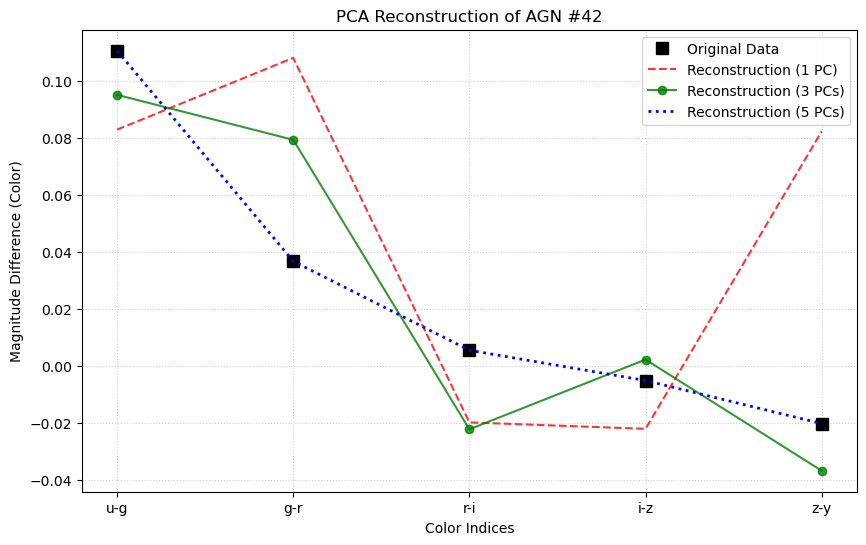

In [35]:
# Show how reconstruction improves as we use more PCAs (for one AGN here)
# 1. Pick an AGN index out of the 100 we have (e.g., 42)
idx = 42 

# 2. Get the scores for this specific AGN
agn_scores = X_reduced[idx].reshape(1, -1)

# 3. Create the "Reduced-Information" score vectors
scores_1pc = np.zeros_like(agn_scores)
scores_1pc[0, 0] = agn_scores[0, 0] # Keep only PC1

scores_3pc = np.zeros_like(agn_scores)
scores_3pc[0, :3] = agn_scores[0, :3] # Keep PC1, PC2, and PC3

scores_5pc = agn_scores # Keep all 5 PCs

# 4. Inverse the PCA
rec_scaled_1pc = pca_model.inverse_transform(scores_1pc)
rec_scaled_3pc = pca_model.inverse_transform(scores_3pc)
rec_scaled_5pc = pca_model.inverse_transform(scores_5pc)

# 5. Inverse the Scaling
# This uses the means/stds calculated in Step 1 (part a)
final_1pc = scaler.inverse_transform(rec_scaled_1pc)[0]
final_3pc = scaler.inverse_transform(rec_scaled_3pc)[0]
final_5pc = scaler.inverse_transform(rec_scaled_5pc)[0]

# The actual original color values for comparison
final_actual = clean_colors[idx] 

# 6. Plotting the results
color_labels = ['u-g', 'g-r', 'r-i', 'i-z', 'z-y']

plt.figure(figsize=(10, 6))
plt.plot(color_labels, final_actual, 'ks', markersize=8, label='Original Data')
plt.plot(color_labels, final_1pc, 'r--', alpha=0.8, label='Reconstruction (1 PC)')
plt.plot(color_labels, final_3pc, 'g-o', alpha=0.8, label='Reconstruction (3 PCs)')
plt.plot(color_labels, final_5pc, 'b:', linewidth=2, label='Reconstruction (5 PCs)')

plt.xlabel('Color Indices')
plt.ylabel('Magnitude Difference (Color)')
plt.title(f'PCA Reconstruction of AGN #{idx}')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

The photometric profile reconstruction demonstrates the recovery of an individual AGN's color signature from a compressed feature space. By iteratively increasing the number of principal components used in the reconstruction process, we see that the reconstruction improves to capture the variance of the specific object. This step-by-step reconstruction provides a direct visual measure of how much information is contained within each subsequent component; while $PC_1$ represents the global trend, the higher-order components add the necessary detail to match the measured photometry. Using all five components results in a perfect overlap with the original data, verifying the mathematical integrity of the transformation.

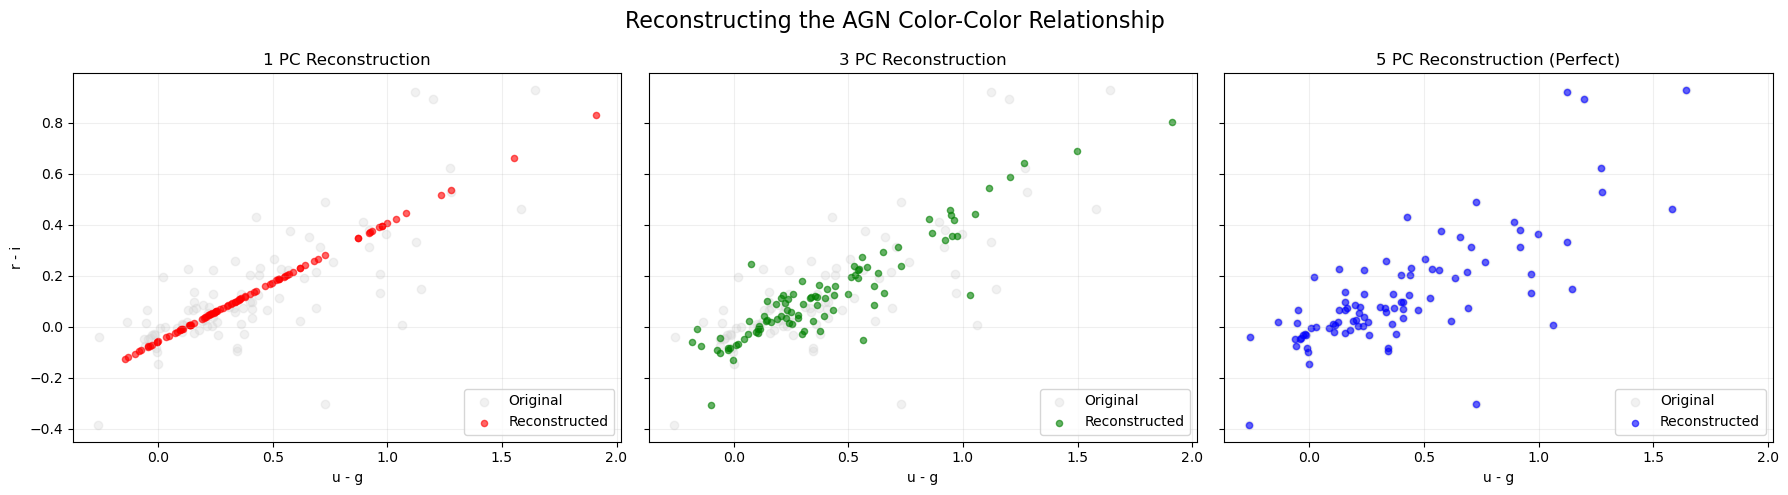

In [53]:
# Scatter plot (shows how PCA simplifies the relationships between filters for the whole population)

# 1. Keep 1, 3, 5 PCs
X_1pc = np.zeros_like(X_reduced)
X_1pc[:, 0] = X_reduced[:, 0]  # Only keep the first column

X_3pc = np.zeros_like(X_reduced)
X_3pc[:, :3] = X_reduced[:, :3]  # Keep first three columns

X_5pc = X_reduced  # Keep all columns (perfect reconstruction)

# 2. Inverse transformation
def get_phys_reconstruction(reduced_data):
    scaled_rec = pca_model.inverse_transform(reduced_data)
    return scaler.inverse_transform(scaled_rec)

phys_1pc = get_phys_reconstruction(X_1pc)
phys_3pc = get_phys_reconstruction(X_3pc)
phys_5pc = get_phys_reconstruction(X_5pc)

# 3. Plotting the scatter plot (u-g vs r-i)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

titles = ['1 PC Reconstruction', '3 PC Reconstruction', '5 PC Reconstruction (Perfect)']
datasets = [phys_1pc, phys_3pc, phys_5pc]
colors = ['red', 'green', 'blue']

for i, ax in enumerate(axes):
    # Plot the original data in light grey background for reference
    ax.scatter(clean_colors[:, 0], clean_colors[:, 2], c='lightgrey', alpha=0.3, label='Original')
    
    # Plot the reconstruction
    ax.scatter(datasets[i][:, 0], datasets[i][:, 2], c=colors[i], alpha=0.6, s=20, label='Reconstructed')
    
    ax.set_title(titles[i])
    ax.set_xlabel('u - g')
    if i == 0:
        ax.set_ylabel('r - i')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.2)

plt.suptitle('Reconstructing the AGN Color-Color Relationship', fontsize=16)
plt.tight_layout()
plt.show()

The population scatter plot reconstruction visualizes the geometric impact of dimensionality reduction on the relationships between specific colors (e.g., $u-g$ versus $r-i$) for the entire AGN sample. When reconstructing the population using only the first principal component, the data collapses onto a single straight line—the axis of maximum variance—essentially creating a "linear skeleton" of the dataset. As additional components are introduced, the reconstruction recovers the "thickness" and subtle correlations of the original color-color cloud. This comparison highlights PCA's ability to simplify complex, high-dimensional distributions into a manageable number of dimensions while preserving the fundamental correlations that define the AGN population's behavior. Finally, with all five components introduced, we get a perfect overlap with the original data as with the previous plot.